In [5]:
pip install boto3

In [ ]:
import boto3
import json

# AWS Credentials

bedrock_runtime = boto3.client(
    service_name="bedrock-runtime",
    region_name=AWS_REGION,
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY
)

MODEL_ID = "amazon.nova-micro-v1:0"
body = {
    "messages": [
        {
            "role": "user",
            "content": [
                {
                    "text": "What is Deep Learning?"
                }
            ]
        }
    ],
   # "system": [{"text": "You are a Tech assistant."}],
    "inferenceConfig": {
        "maxTokens": 100,
        "temperature": 1.0,
        # "topP":0.7
    }
}

response = bedrock_runtime.invoke_model(
    modelId=MODEL_ID,
    body=json.dumps(body),
    contentType="application/json",
    accept="application/json"
)

response_body = json.loads(response["body"].read())

print(json.dumps(response_body, indent=2))



final_response = response_body["output"]["message"]["content"][0]["text"]

print(f"Model Response : {final_response}")

{
  "output": {
    "message": {
      "content": [
        {
          "text": "Deep Learning is a subset of machine learning, which itself is a branch of artificial intelligence (AI). Deep Learning focuses on algorithms inspired by the structure and function of the brain's neural networks. These algorithms are designed to recognize patterns in data through multiple layers of processing. Each layer processes data at a different level of abstraction, allowing the model to learn and improve from experience without being explicitly programmed.\n\n### Key Components of Deep Learning:\n\n1. **Neural Networks**:\n    - **Structure**: Deep"
        }
      ],
      "role": "assistant"
    }
  },
  "stopReason": "max_tokens",
  "usage": {
    "inputTokens": 5,
    "outputTokens": 100,
    "totalTokens": 105,
    "cacheReadInputTokenCount": 0,
    "cacheWriteInputTokenCount": 0
  }
}
Model Response : Deep Learning is a subset of machine learning, which itself is a branch of artificial intellig

In [7]:
# compute token costs using existing response_body
usage = response_body.get("usage", {})
input_tokens = usage.get("inputTokens", 0)
output_tokens = usage.get("outputTokens", 0)
total_tokens = usage.get("totalTokens", input_tokens + output_tokens)

cost_per_m_input = 0.035  # $ per 1M input tokens
cost_per_m_output = 0.14  # $ per 1M output tokens

cost_input = input_tokens * (cost_per_m_input / 1_000_000)
cost_output = output_tokens * (cost_per_m_output / 1_000_000)
total_cost = cost_input + cost_output

print(f"Input tokens: {input_tokens}")
print(f"Output tokens: {output_tokens}")
print(f"Total tokens: {total_tokens}")
print(f"Input cost: ${cost_input:.8f}")
print(f"Output cost: ${cost_output:.8f}")
print(f"Total cost: ${total_cost:.8f}")

Input tokens: 5
Output tokens: 100
Total tokens: 105
Input cost: $0.00000018
Output cost: $0.00001400
Total cost: $0.00001418


###model with temp=0.3 and topp=0.7

Model Response : Deep Learning is a subset of machine learning that involves the use of artificial neural networks with multiple layers to model and solve complex problems. Here are some key points about Deep Learning:

1. **Neural Networks**: Deep Learning models are based on neural networks, which are computational models inspired by the human brain. These networks consist of layers of interconnected nodes (neurons).

2. **Layers**: Unlike traditional neural networks, deep learning networks have many layers (hence "deep"). These layers can include:

High temp + low topp = the out put is creative but guarded 
low temp + high topp = focused and precised( no need of topp if temp is low)
low temp + low topp = the out is more deterministic 
high temp + high topp = most creative 

## temp =0.0 
Model Response : Deep Learning is a subset of machine learning that is based on artificial neural networks with multiple layers (hence "deep"). These networks are designed to process large amounts of data and to identify patterns through the following steps:

1. **Architecture**: Deep learning models typically consist of an input layer, several hidden layers, and an output layer. Each layer consists of nodes (also called neurons) that perform computations on the input data.

2. **Training**: Deep learning models are trained using large datasets. The training

# temp= 0.3
Model Response : Deep Learning is a subset of machine learning that focuses on artificial neural networks with multiple layers (hence "deep") that are capable of learning representations of data that are significantly more abstract and complex than those learned by traditional machine learning algorithms. Here are some key points to understand deep learning:

1. **Neural Networks**: Deep learning models are based on artificial neural networks (ANNs), which are computational models inspired by the way the human brain processes information. These networks consist of layers of interconnected nodes (neuron

# temp 0.5
Model Response : Deep Learning is a subset of machine learning that utilizes artificial neural networks with multiple layers to model and solve complex problems. It is inspired by the structure and functioning of the human brain, aiming to simulate the way neurons in the brain process information.

### Key Concepts:

1. **Neural Networks**:
   - **Structure**: Deep learning models consist of layers of interconnected nodes (neurons). Each layer transforms the input data through a series of mathematical operations.
   - **Types**:

## temp= 1.0 
Model Response : Deep Learning is a subset of machine learning that focuses on neural networks with many layers (deep neural networks). These networks are designed to process data in a way that mimics the way the human brain operates to some extent. Here are some key points about deep learning:

1. **Architecture**:
   - **Neurons and Layers**: Deep learning models are composed of layers of interconnected neurons. Each neuron performs a transformation on the input data.
   - **Hidden Layers**: Intermediate layers (hidden layers) extract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 6.0 MB/s  0:00:01 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


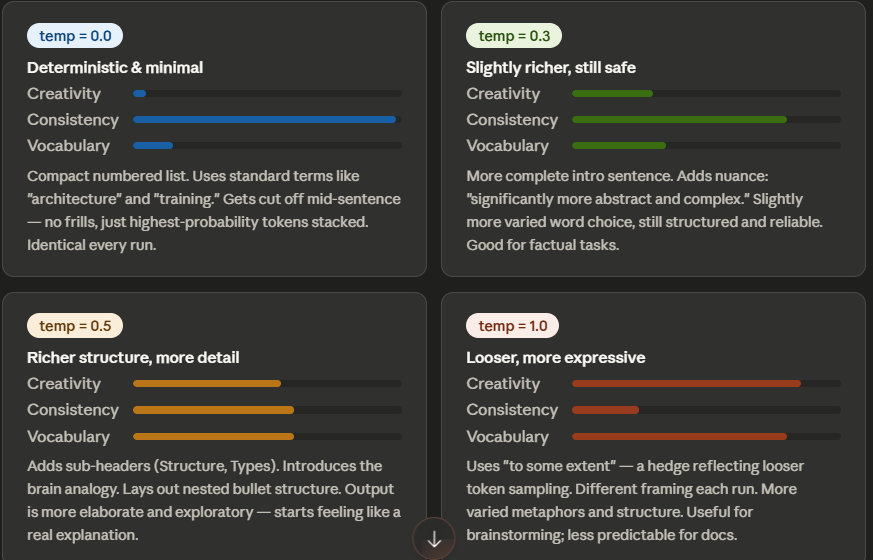

In [10]:
%pip install pillow

from PIL import Image
img = Image.open("/home/sathw/bootcamp-project/Screenshot 2026-06-01 175752.png")
img.show()